In [23]:
# Function to generate progress bar images
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


# Shared data setup
csv_path = "Cross_case_recovery_timelines.csv"
df = pd.read_csv(csv_path)

MILESTONE_PATTERNS = {
    "Permit application": ["permit application"],
    "Permit issue": ["permit issue", "permits issued", "permit issued", "permitted"],
    "Construction complete": ["construction complete", "construction complete", "occupied"],
}

fire_map = {}
for col in df.columns:
    if " - " not in col:
        continue
    fire, metric = col.split(" - ", 1)
    metric_norm = metric.strip().lower()

    matched_milestone = None
    for milestone, patterns in MILESTONE_PATTERNS.items():
        if any(pattern in metric_norm for pattern in patterns):
            matched_milestone = milestone
            break

    if matched_milestone is None:
        continue

    fire_map.setdefault(fire, {})[matched_milestone] = col

fires = sorted(fire_map.keys())

def value_at_checkpoint(series, month_series, checkpoint_month):
    series_num = pd.to_numeric(series, errors="coerce")
    valid = series_num.notna() & month_series.notna()
    if not valid.any():
        return np.nan

    if checkpoint_month is None:
        return float(series_num[valid].iloc[-1])

    eligible = valid & (month_series <= checkpoint_month)
    if not eligible.any():
        return np.nan

    return float(series_num[eligible].iloc[-1])


def faded_color(color_hex, fade_to_gray=0.65, gray_level=0.75):
    base_rgb = np.array(mcolors.to_rgb(color_hex))
    gray_rgb = np.array([gray_level, gray_level, gray_level])
    return tuple((1 - fade_to_gray) * base_rgb + fade_to_gray * gray_rgb)


def make_progress_bar_images(output_dir=Path("Results") / "disaster_progress_slides"):
    if "df" not in globals() or "fires" not in globals() or "fire_map" not in globals():
        raise ValueError("Run the setup cell first so df, fires, and fire_map are available.")

    checkpoint_months = [
        (3, "3 months"),
        (6, "6 months"),
        (9, "9 months"),
        (12, "12 months"),
        (24, "2 years"),
        (36, "3 years"),
        (None, "Full data"),
    ]

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Fire order and labels for images (Tubbs removed)
    slide_fire_order = ["Camp", "Carr", "Marshall", "Maui", "LA"]
    slide_fire_order = [f for f in slide_fire_order if f in fires]
    if not slide_fire_order:
        slide_fire_order = [f for f in fires if f != "Tubbs"]

    fire_label_base = {
        "Camp": "2018 Camp (14,352)",
        "Carr": "2018 Carr (1,300)",
        "LA": "2025 LA (6,571)",
        "Marshall": "2021 Marshall (1,300)",
        "Maui": "2023 Maui (2,000)",
    }

    bar_colors = {
        "Permit issue": "#1f77b4",
        "Construction complete": "#2ca02c",
    }

    month_series = pd.to_numeric(df["Month"], errors="coerce")

    checkpoint_data = {}
    for checkpoint_month, checkpoint_label in checkpoint_months:
        rows = []
        for fire in fires:
            permit_col = fire_map.get(fire, {}).get("Permit issue")
            complete_col = fire_map.get(fire, {}).get("Construction complete")

            permit_val = (
                value_at_checkpoint(df[permit_col], month_series, checkpoint_month)
                if permit_col is not None
                else np.nan
            )
            complete_val = (
                value_at_checkpoint(df[complete_col], month_series, checkpoint_month)
                if complete_col is not None
                else np.nan
            )

            rows.append(
                {
                    "Fire": fire,
                    "Permit issue": permit_val,
                    "Construction complete": complete_val,
                }
            )

        checkpoint_data[checkpoint_label] = pd.DataFrame(rows)

    ordered_checkpoints = [(m, label) for m, label in checkpoint_months if label in checkpoint_data]

    # User-defined inactivity timing (in months)
    inactive_after_months = {
        "LA": 12,
        "Maui": 12,
        "Marshall": 24,
    }

    data_month_notes = {
        "LA": 15,
        "Maui": 19,
        "Marshall": 37,
    }

    # Compute months of available data per fire (based on Permit issue or Construction complete)
    fire_data_months = {}
    month_numeric = pd.to_numeric(df["Month"], errors="coerce")
    for fire in fires:
        permit_col = fire_map.get(fire, {}).get("Permit issue")
        complete_col = fire_map.get(fire, {}).get("Construction complete")

        valid_any = pd.Series(False, index=df.index)
        if permit_col is not None:
            valid_any = valid_any | pd.to_numeric(df[permit_col], errors="coerce").notna()
        if complete_col is not None:
            valid_any = valid_any | pd.to_numeric(df[complete_col], errors="coerce").notna()

        valid_months = month_numeric[valid_any & month_numeric.notna()]
        fire_data_months[fire] = int(valid_months.max()) if not valid_months.empty else 0

    image_paths = []
    for checkpoint_month, checkpoint_label in ordered_checkpoints:
        checkpoint_df = checkpoint_data[checkpoint_label]
        plot_df = checkpoint_df[checkpoint_df["Fire"] != "Tubbs"]
        plot_df = plot_df.set_index("Fire").reindex(slide_fire_order).reset_index()

        active_rows = []
        for fire in plot_df["Fire"]:
            if fire == "Marshall" and checkpoint_label == "3 years":
                active_rows.append(True)
                continue

            threshold = inactive_after_months.get(fire)
            if threshold is None or checkpoint_month is None:
                active_rows.append(True)
            else:
                active_rows.append(checkpoint_month <= threshold)

        active_mask = np.array(active_rows, dtype=bool)

        permit_colors = [
            bar_colors["Permit issue"] if active else faded_color(bar_colors["Permit issue"])
            for active in active_mask
        ]
        complete_colors = [
            bar_colors["Construction complete"] if active else faded_color(bar_colors["Construction complete"])
            for active in active_mask
        ]

        permit_vals_raw = plot_df["Permit issue"].values
        complete_vals_raw = plot_df["Construction complete"].values
        permit_vals = plot_df["Permit issue"].fillna(0).values
        complete_vals = plot_df["Construction complete"].fillna(0).values

        y = np.arange(len(plot_df))
        bar_h = 0.36

        fig, ax = plt.subplots(figsize=(11, 6.2))
        ax.barh(
            y - bar_h / 2,
            permit_vals,
            height=bar_h,
            color=permit_colors,
            label="Permits Issued",
        )
        ax.barh(
            y + bar_h / 2,
            complete_vals,
            height=bar_h,
            color=complete_colors,
            label="Construction complete",
        )

        y_labels = []
        for fire, active in zip(plot_df["Fire"], active_mask):
            base_label = fire_label_base.get(fire, fire)
            if checkpoint_label == "Full data":
                y_labels.append(f"{base_label} | {fire_data_months.get(fire, 0)} mo data")
            elif (not active) and (fire in data_month_notes):
                y_labels.append(f"{base_label} | {data_month_notes[fire]} mo data")
            else:
                y_labels.append(base_label)

        ax.set_xlim(0, 100)
        ax.set_yticks(y)
        ax.set_yticklabels(y_labels, fontsize=15, fontweight="bold")
        ax.set_xlabel("Percent of homes", fontsize=15, fontweight="bold")
        ax.tick_params(axis="x", labelsize=13)
        ax.grid(axis="x", linestyle="--", alpha=0.35)

        legend_handles = [
            Patch(facecolor=bar_colors["Permit issue"], label="Permits Issued"),
            Patch(facecolor=bar_colors["Construction complete"], label="Construction complete"),
            Patch(facecolor=faded_color("#7f7f7f", fade_to_gray=0.2, gray_level=0.85), label="Inactive"),
        ]
        ax.legend(handles=legend_handles, loc="lower right", prop={"weight": "bold", "size": 13})

        for i, (p_raw, c_raw, p, c, active) in enumerate(
            zip(permit_vals_raw, complete_vals_raw, permit_vals, complete_vals, active_mask)
        ):
            text_color = "black" if active else "#6b6b6b"
            if pd.notna(p_raw):
                ax.text(min(p + 1, 99), i - bar_h / 2, f"{p:.1f}%", va="center", fontsize=12, color=text_color)
            if pd.notna(c_raw):
                ax.text(min(c + 1, 99), i + bar_h / 2, f"{c:.1f}%", va="center", fontsize=12, color=text_color)

        ax.invert_yaxis()
        plt.tight_layout()

        img_path = output_dir / f"progress_{checkpoint_label.replace(' ', '_')}.png"
        fig.savefig(img_path, dpi=220)
        plt.close(fig)
        image_paths.append((checkpoint_label, img_path))

    print("Images created:")
    for label, path in image_paths:
        print(f"- {label}: {path}")

    return image_paths


# Run to generate the progress-bar images
# make_progress_bar_images()




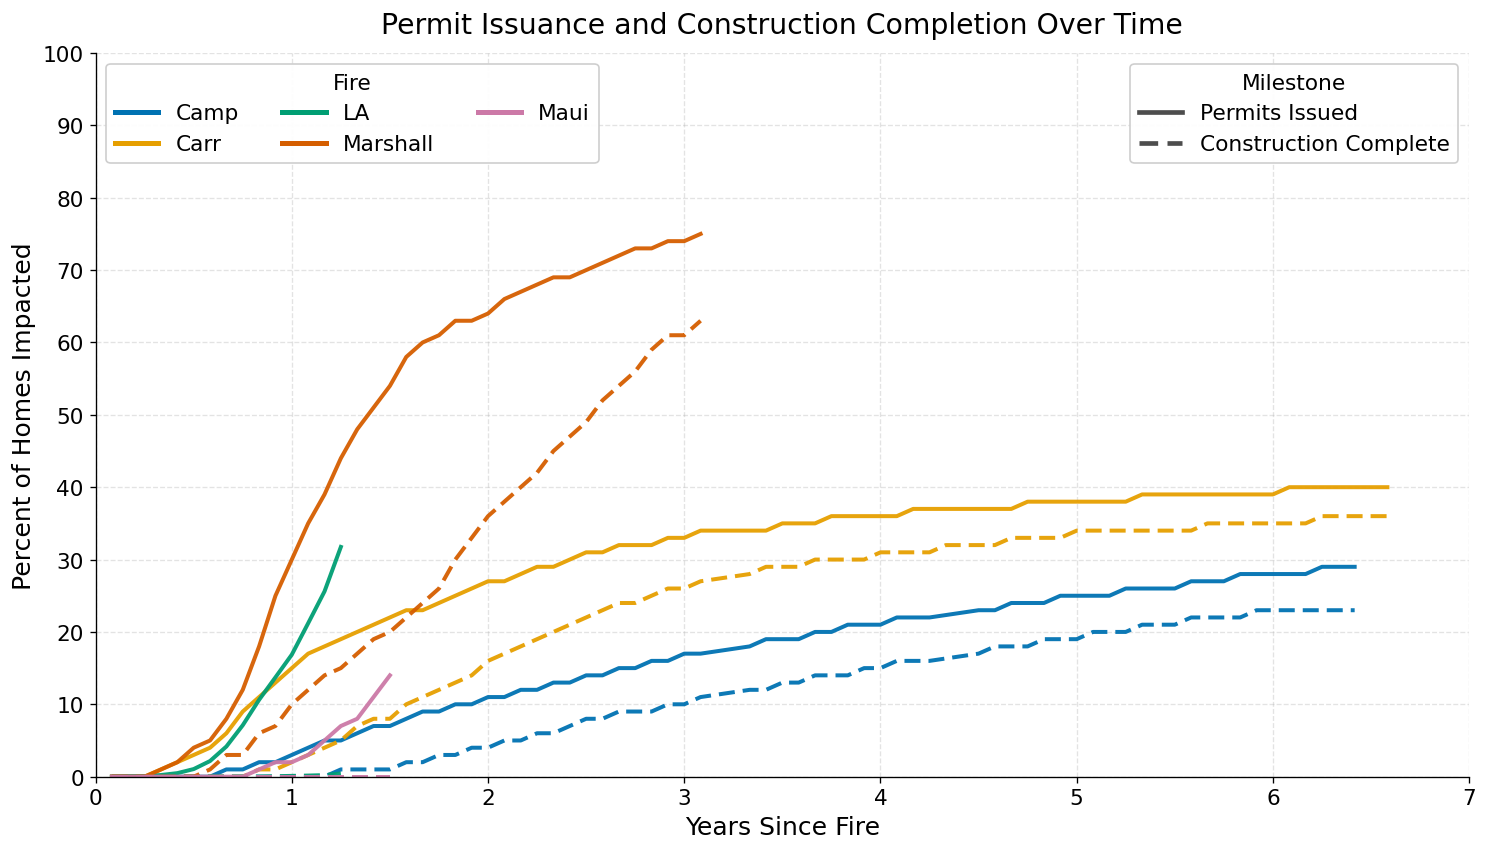

In [24]:
# Improved comparison plot: one color per fire, one line style per milestone
import numpy as np
from matplotlib.lines import Line2D

# Reset any previous global style/font changes in the notebook session
plt.rcdefaults()

# Data setup for this chart
csv_path = "Cross_case_recovery_timelines.csv"
df = pd.read_csv(csv_path)

MILESTONE_PATTERNS = {
    "Permit application": ["permit application"],
    "Permit issue": ["permit issue", "permits issued", "permit issued", "permitted"],
    "Construction complete": ["construction complete", "construction complete", "occupied"],
}

fire_map = {}
for col in df.columns:
    if " - " not in col:
        continue
    fire, metric = col.split(" - ", 1)
    metric_norm = metric.strip().lower()

    matched_milestone = None
    for milestone, patterns in MILESTONE_PATTERNS.items():
        if any(pattern in metric_norm for pattern in patterns):
            matched_milestone = milestone
            break

    if matched_milestone is None:
        continue

    fire_map.setdefault(fire, {})[matched_milestone] = col

required_fires = ["Camp", "Carr", "LA", "Marshall", "Maui"]

if "df" not in globals() or "fire_map" not in globals():
    raise ValueError("Run the previous setup cells first so df and fire_map are available.")

month_vals = pd.to_numeric(df["Month"], errors="coerce")
year_vals = month_vals / 12.0

labels = {
    "Camp": "Camp",
    "Carr": "Carr",
    "LA": "LA",
    "Marshall": "Marshall",
    "Maui": "Maui",
}

# Colorblind-friendly palette with stronger contrast
fire_colors = {
    "Camp": "#0072B2",
    "Carr": "#E69F00",
    "LA": "#009E73",
    "Marshall": "#D55E00",
    "Maui": "#CC79A7",
}

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=120)

for fire in required_fires:
    if fire not in fire_map:
        continue

    color = fire_colors.get(fire, "#4d4d4d")

    permit_col = fire_map[fire].get("Permit issue")
    complete_col = fire_map[fire].get("Construction complete")

    if permit_col is not None and permit_col in df.columns:
        y_permit = pd.to_numeric(df[permit_col], errors="coerce")
        valid_permit = year_vals.notna() & y_permit.notna()
        x_perm = year_vals[valid_permit].to_numpy()
        y_perm = y_permit[valid_permit].to_numpy()
        if len(x_perm) > 0:
            order = np.argsort(x_perm)
            x_perm, y_perm = x_perm[order], y_perm[order]
            ax.plot(
                x_perm,
                y_perm,
                color=color,
                linewidth=2.4,
                linestyle="-",
                alpha=0.95,
            )

    if complete_col is not None and complete_col in df.columns:
        y_complete = pd.to_numeric(df[complete_col], errors="coerce")
        valid_complete = year_vals.notna() & y_complete.notna()
        x_comp = year_vals[valid_complete].to_numpy()
        y_comp = y_complete[valid_complete].to_numpy()
        if len(x_comp) > 0:
            order = np.argsort(x_comp)
            x_comp, y_comp = x_comp[order], y_comp[order]
            ax.plot(
                x_comp,
                y_comp,
                color=color,
                linewidth=2.4,
                linestyle=(0, (4, 2)),
                alpha=0.95,
            )

# Axis formatting
x_max = float(np.nanmax(year_vals.to_numpy())) if year_vals.notna().any() else 0
x_upper = int(np.ceil(max(1, x_max)))
ax.set_xlim(0, x_upper)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, x_upper + 1, 1))
ax.set_yticks(np.arange(0, 101, 10))

# Larger typography for all plot text
axis_label_size = 15
title_size = 17
tick_label_size = 13
legend_text_size = 13
legend_title_size = 13

ax.set_xlabel("Years Since Fire", fontsize=axis_label_size)
ax.set_ylabel("Percent of Homes Impacted", fontsize=axis_label_size)
ax.set_title("Permit Issuance and Construction Completion Over Time", fontsize=title_size, pad=12)
ax.tick_params(axis="both", labelsize=tick_label_size)

# Cleaner, softer grid and frame
ax.grid(True, axis="both", linestyle="--", linewidth=0.8, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Two concise legends: color encodes fire, line style encodes milestone
fire_handles = [
    Line2D([0], [0], color=fire_colors[f], lw=3, label=labels[f])
    for f in required_fires
    if f in fire_colors
]
style_handles = [
    Line2D([0], [0], color="#4d4d4d", lw=2.8, linestyle="-", label="Permits Issued"),
    Line2D([0], [0], color="#4d4d4d", lw=2.8, linestyle=(0, (4, 2)), label="Construction Complete"),
]

legend_fires = ax.legend(
    handles=fire_handles,
    title="Fire",
    ncol=3,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=legend_text_size,
    title_fontsize=legend_title_size,
)
ax.add_artist(legend_fires)
ax.legend(
    handles=style_handles,
    title="Milestone",
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    fontsize=legend_text_size,
    title_fontsize=legend_title_size,
)

plt.tight_layout()
plt.show()
